In [4]:
!pip install faker
import pandas as pd
import numpy as np
from faker import Faker
import random
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 188.5 kB/s eta 0:00:00


In [5]:
fake = Faker()

countries = ['India', 'USA', 'Brazil', 'UK', 'Germany', 'France', 'Italy', 'Spain']

data = []

for _ in range(1000):
    date = fake.date_between(start_date='-2y', end_date='today')
    country = random.choice(countries)

    confirmed = random.randint(1000, 100000)
    deaths = random.randint(10, confirmed // 10)
    recovered = random.randint(100, confirmed - deaths)

    active = confirmed - deaths - recovered

    data.append([date, country, confirmed, deaths, recovered, active])

df = pd.DataFrame(data, columns=['Date', 'Country', 'Confirmed', 'Deaths', 'Recovered', 'Active'])

df.head()

,Date,Country,Confirmed,Deaths,Recovered,Active
0,2025-03-25,Germany,34893,3256,1688,29949
1,2024-10-07,Brazil,61739,2369,11258,48112
2,2025-06-05,Brazil,15261,560,7365,7336
3,2026-01-17,Spain,15684,1001,2701,11982
4,2025-01-21,USA,31781,2019,13954,15808


In [6]:
df['Date'] = pd.to_datetime(df['Date'])
df.fillna(0, inplace=True)
df.drop_duplicates(inplace=True)

In [7]:
print("Total Confirmed:", df['Confirmed'].sum())
print("Total Deaths:", df['Deaths'].sum())
print("Total Recovered:", df['Recovered'].sum())

Total Confirmed: 50729865
Total Deaths: 2601529
Total Recovered: 23654802


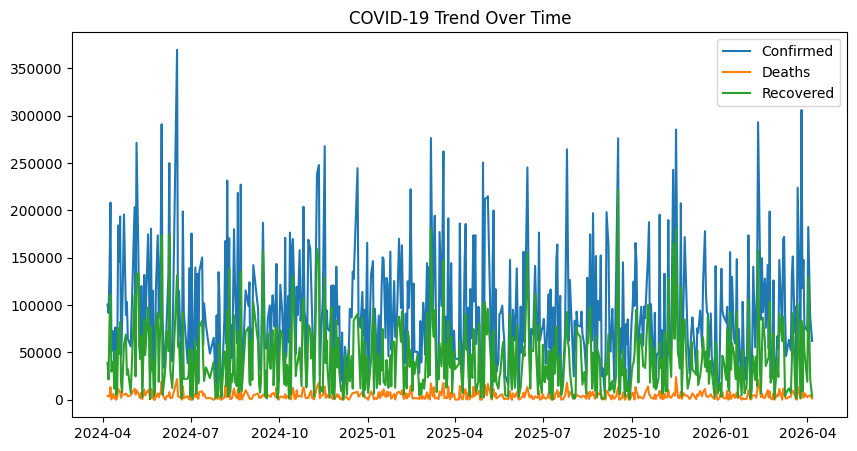

In [8]:
trend = df.groupby('Date')[['Confirmed', 'Deaths', 'Recovered']].sum().reset_index()

plt.figure(figsize=(10,5))
plt.plot(trend['Date'], trend['Confirmed'], label='Confirmed')
plt.plot(trend['Date'], trend['Deaths'], label='Deaths')
plt.plot(trend['Date'], trend['Recovered'], label='Recovered')
plt.legend()
plt.title("COVID-19 Trend Over Time")
plt.show()

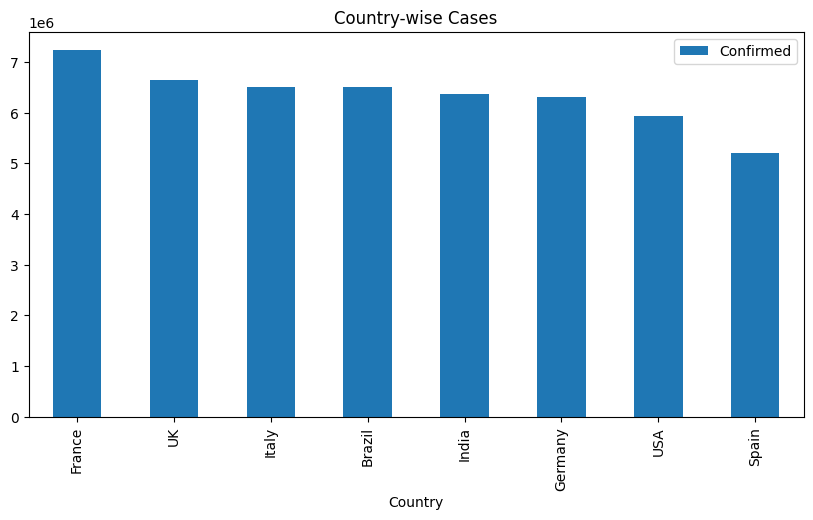

In [9]:
country_data = df.groupby('Country')[['Confirmed']].sum().sort_values(by='Confirmed', ascending=False)

country_data.plot(kind='bar', figsize=(10,5), title="Country-wise Cases")
plt.show()

In [10]:
top5 = country_data.head(5).reset_index()

px.pie(top5, values='Confirmed', names='Country', title='Top 5 Countries').show()

In [11]:
px.scatter(df, x='Confirmed', y='Deaths', color='Country',
           title='Confirmed vs Deaths').show()

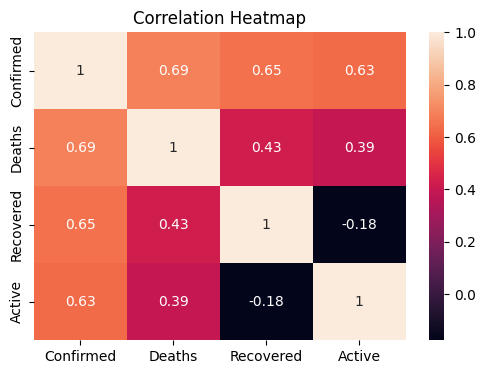

In [12]:
plt.figure(figsize=(6,4))
sns.heatmap(df[['Confirmed','Deaths','Recovered','Active']].corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()